<a href="https://colab.research.google.com/github/lennisflores/Actividades/blob/main/AF5_Procesamiento_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Actividad 5: Procesamiento de conjuntos de datos en Python**
En esta actividad realizamos el procesamiento y análisis de un conjunto de datos utilizando Python en Google Colab. Aplicamos técnicas básicas de exploración, limpieza y filtrado de datos usando las librerías pandas, numpy y matplotlib.

In [41]:
#INT.ARTIFICIALY REDES NEURONALES N4
#Actividad 5: Procesamiento de conjuntos de datos en Python
#2022917 FLORES ARREOLA LENNIS VALERIA
#2044749 HERNÁNDEZ SANTILLAN JOSUE URIEL
#2001320 OLIVA ESTRADA XOCHITL
#2108228 TORRES RAMOS JARED ISAI
#2222972 DE SANTIAGO PÉREZ MARÍA TERESA

# **1.Cargar el dataset con pandas**

En esta sección importamos las librerías necesarias para trabajar con los datos.
Pandas nos permite manipular el dataset, numpy nos ayuda con operaciones numéricas y matplotlib se utilizará para visualizar la información.

In [42]:
import pandas as pd #importar la libreria de pandas
import numpy as np #libreria 1
import matplotlib.pyplot as plt #libreria 2

Aquí cargamos el archivo robot_sensors.csv utilizando la función read_csv() de pandas.

In [43]:
df = pd.read_csv('/content/robot_sensors.csv') #cargar datos

En este paso analizamos las propiedades del dataset utilizando shape e info().
Esto nos permite conocer el número de filas y columnas, los tipos de datos y detectar si existen valores nulos.

In [44]:
print(df.shape) #propiedades de la tabla

(1000, 4)


In [45]:
print(df.info()) #informacion de las columnas DATOS QUE ESTAN EN LA TABLA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tiempo (s)        1000 non-null   int64  
 1   Distancia (cm)    970 non-null    float64
 2   Velocidad (cm/s)  970 non-null    float64
 3   Temperatura (°C)  970 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 31.4 KB
None


# **2.Mostrar primeras filas del dataset**
Mostramos las primeras 10 filas con head() para observar cómo están organizados los datos.


In [46]:
print(df.head(10)) #Muestra primeras 10 lineas del dataset

   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0           0       43.708611          9.256646         23.925585
1           1       95.564288         27.095047         23.704682
2           2       75.879455         43.647292         33.593819
3           3       63.879264         36.611244         23.743193
4           4       24.041678         40.328057         24.079246
5           5       24.039507         32.939168         31.390974
6           6       15.227525         34.613828         26.746098
7           7       87.955853         42.459783         31.650658
8           8       64.100351         12.483400         20.980492
9           9       73.726532         24.471248         27.313568


# **3.Limpiar los datos**

# **a.Eliminar filas con valores nulos**
Primero verificamos cuántos valores nulos existen en cada columna utilizando isnull().sum().
Después eliminamos las filas que contienen datos faltantes con dropna().

In [47]:
print(df.isnull().sum()) #Detectar valores nulos

Tiempo (s)           0
Distancia (cm)      30
Velocidad (cm/s)    30
Temperatura (°C)    30
dtype: int64


In [48]:
df = df.dropna() #Eliminar filas con valres nulos

En esta parte comprobamos nuevamente la información del dataset para asegurarnos de que los valores nulos fueron eliminados correctamente y observar cómo cambió la cantidad de datos.

In [49]:
print(df.isnull().sum()) #Revisar que valores nulos fueran eliminados

Tiempo (s)          0
Distancia (cm)      0
Velocidad (cm/s)    0
Temperatura (°C)    0
dtype: int64


In [50]:
print(df.info()) #Tabla despues de eliminar valores nulos

<class 'pandas.core.frame.DataFrame'>
Index: 913 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tiempo (s)        913 non-null    int64  
 1   Distancia (cm)    913 non-null    float64
 2   Velocidad (cm/s)  913 non-null    float64
 3   Temperatura (°C)  913 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 35.7 KB
None


# **b.Filtrado de valores atípicos**
Aquí filtramos posibles valores inválidos o fuera de rango, como tiempos, distancias o velocidades negativas, ya que físicamente no tendrían sentido en este contexto.
Si después del filtrado no cambia el número de filas, significa que no existían valores negativos en esas columnas.

In [51]:
# Filtrar tiempos negativos
df = df[df["Tiempo (s)"] >= 0]

# Filtrar distancias negativas
df = df[df["Distancia (cm)"] >= 0]

# Filtramos velocidades negativas
df = df[df["Velocidad (cm/s)"] >= 0]

#**4.Normalizar los datos numéricos con Min-Max Scaling**

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Transforma todos los valores numéricos al rango [0, 1].

In [52]:
# Definimos las columnas que queremos normalizar (las numéricas de sensores)
cols_to_normalize = ["Distancia (cm)", "Velocidad (cm/s)", "Temperatura (°C)"]

# Creamos una copia del dataframe para no perder los datos originales si los necesitan luego
df_norm = df.copy()

# Aplicamos la fórmula Min-Max
df_norm[cols_to_normalize] = (df[cols_to_normalize] - df[cols_to_normalize].min()) / (df[cols_to_normalize].max() - df[cols_to_normalize].min())

# Mostramos los primeros datos normalizados para verificar
print("Datos normalizados (Rango 0-1):")
print(df_norm.head())

Datos normalizados (Rango 0-1):
   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0           0        0.371735          0.182609          0.262269
1           1        0.950755          0.540740          0.247509
2           2        0.730954          0.873049          0.908233
3           3        0.596960          0.731791          0.250082
4           4        0.152134          0.806411          0.272535


#**5.Visualizar los datos normalizados usando matplotlib**


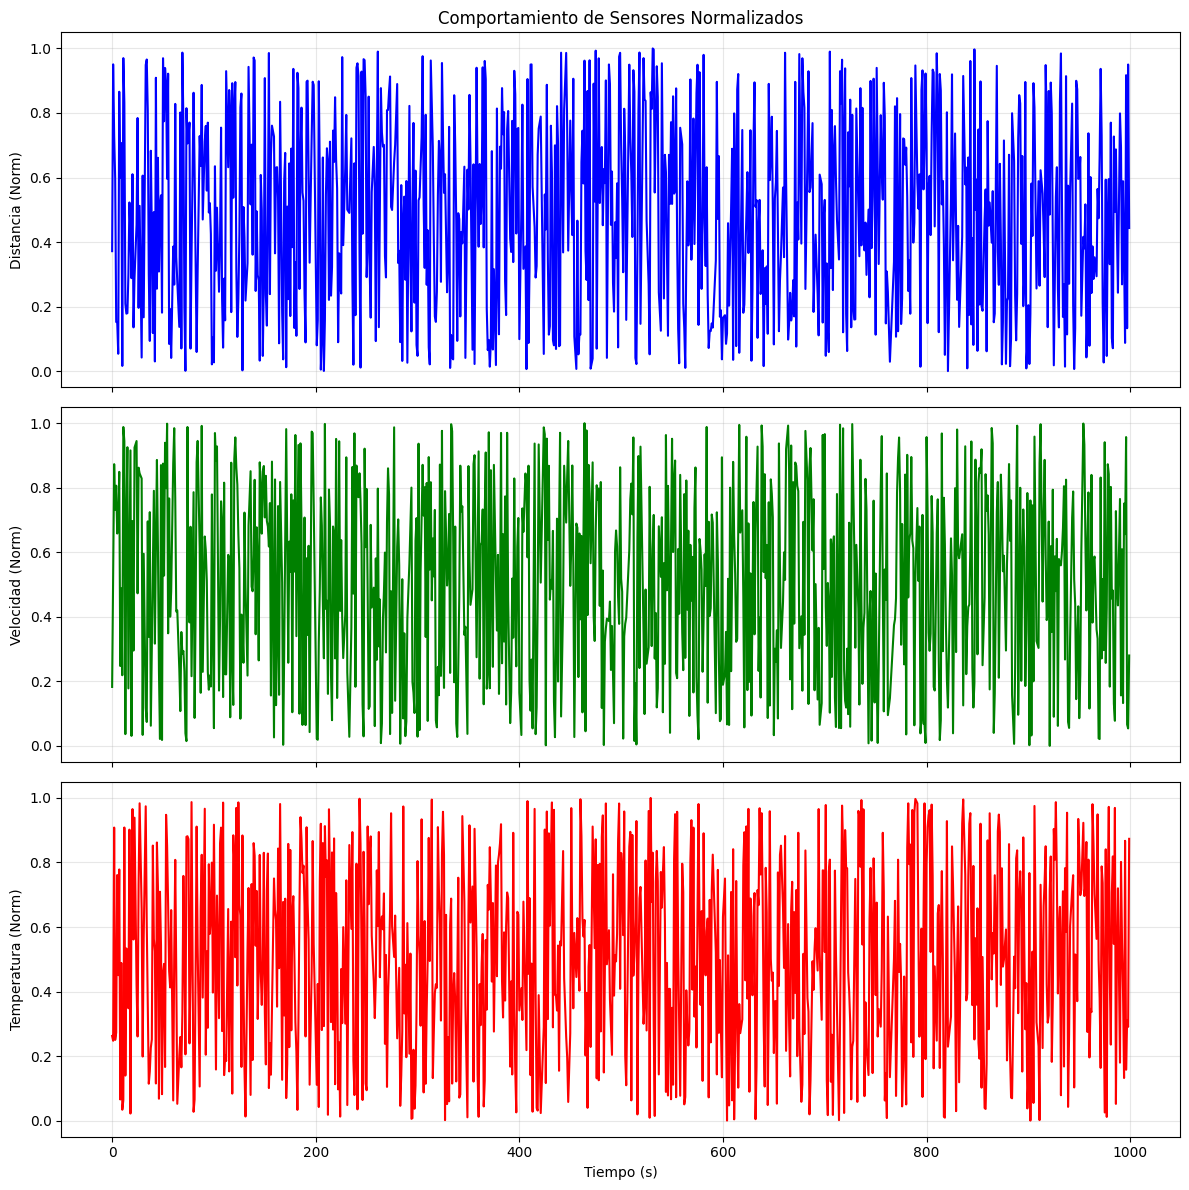

In [53]:
import matplotlib.pyplot as plt

# Creamos una figura con 3 subgráficas (3 filas, 1 columna)
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# 1. Gráfica de Distancia
axs[0].plot(df_norm["Tiempo (s)"], df_norm["Distancia (cm)"], color='blue')
axs[0].set_ylabel("Distancia (Norm)")
axs[0].set_title("Comportamiento de Sensores Normalizados")
axs[0].grid(True, alpha=0.3)

# 2. Gráfica de Velocidad
axs[1].plot(df_norm["Tiempo (s)"], df_norm["Velocidad (cm/s)"], color='green')
axs[1].set_ylabel("Velocidad (Norm)")
axs[1].grid(True, alpha=0.3)

# 3. Gráfica de Temperatura
axs[2].plot(df_norm["Tiempo (s)"], df_norm["Temperatura (°C)"], color='red')
axs[2].set_ylabel("Temperatura (Norm)")
axs[2].set_xlabel("Tiempo (s)")
axs[2].grid(True, alpha=0.3)

# Ajustamos el diseño para que no se encimen los títulos
plt.tight_layout()
plt.show()